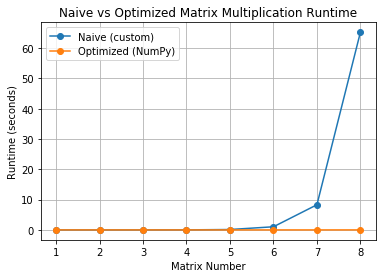

Matrix 1: 3x3 | naive = 0.000049s | numpy = 0.000540s
Matrix 2: 6x6 | naive = 0.000285s | numpy = 0.000010s
Matrix 3: 12x12 | naive = 0.002176s | numpy = 0.000011s
Matrix 4: 24x24 | naive = 0.016711s | numpy = 0.000037s
Matrix 5: 48x48 | naive = 0.132423s | numpy = 0.000041s
Matrix 6: 96x96 | naive = 1.038265s | numpy = 0.003046s
Matrix 7: 192x192 | naive = 8.301596s | numpy = 0.000590s
Matrix 8: 384x384 | naive = 65.241733s | numpy = 0.004545s


In [14]:
import numpy as np
import time
import matplotlib.pyplot as plt

# matrix multiplication from lecture
# this is the manual way with the 3 nested loops
def my_matmul(A, B):
    n = len(A)
    C = np.zeros((n, n))

    for i in range(n):
        for j in range(n):
            for k in range(n):
                C[i][j] += A[i][k] * B[k][j]

    return C


# lists to store stuff
matrix_nums = []
sizes = []
naive_times = []
numpy_times = []

# first matrix is 3x3
size = 3

# build 8 pairs total
for i in range(8):
    matrix_nums.append(i + 1)
    sizes.append(size)

    # random matrices for this round
    A = np.random.rand(size, size)
    B = np.random.rand(size, size)

    # time the custom version
    start = time.perf_counter()
    C1 = my_matmul(A, B)
    end = time.perf_counter()
    naive_times.append(end - start)

    # time the optimized numpy version
    start = time.perf_counter()
    C2 = A @ B
    end = time.perf_counter()
    numpy_times.append(end - start)

    # just checking they give basically the same answer
    assert np.allclose(C1, C2)

    # next matrix is 2x bigger in rows and columns
    size *= 2


# plot runtime vs matrix number 
plt.plot(matrix_nums, naive_times, 'o-', label='Naive (custom)')
plt.plot(matrix_nums, numpy_times, 'o-', label='Optimized (NumPy)')

plt.xlabel("Matrix Number")
plt.ylabel("Runtime (seconds)")
plt.title("Naive vs Optimized Matrix Multiplication Runtime")
plt.legend()
plt.grid(True)
plt.show()


# printout so i can see what sizes each matrix number was
for i in range(8):
    print(f"Matrix {matrix_nums[i]}: {sizes[i]}x{sizes[i]} | naive = {naive_times[i]:.6f}s | numpy = {numpy_times[i]:.6f}s")

This code compares a custom matrix multiplication implementation with NumPy’s optimized version by measuring runtime across increasing matrix sizes. The naive method has (O(n^3)) time complexity due to the triple nested loops, making it significantly slower as matrix size grows, while NumPy uses optimized routines that are much more efficient in practice.